# Investment Strategy Backtest - WTI Crude Oil Direction Models

This notebook backtests trading strategies derived from the MLP+ElasticNet and XGBoost direction classifiers trained in the other notebooks. Each model outputs a binary direction prediction (+1 = up, -1 = down) and a class probability, both of which are used to construct positions.

**Strategies evaluated:**
| Strategy | Description |
|---|---|
| MLP+EN Long-Short | ±1 position following MLP+EN prediction every day |
| MLP+EN Filtered | Same, but only trade when confidence exceeds threshold |
| XGBoost Long-Short | ±1 position following XGBoost prediction every day |
| XGBoost Filtered | Same, but only trade when confidence exceeds threshold |
| Ensemble | Average both models' probabilities, trade combined signal |
| Buy & Hold | Always long - baseline benchmark |

**Prerequisite:** `predictions/` CSVs must exist. Run `python script_00_generate_preds.py` if missing.

## 0. Setup

In [43]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from data_utils import load_price, PRICE_FILE

PRED_DIR = Path("../predictions")

# Verify prediction files exist
required = ["xgb_val_preds.csv", "xgb_test_preds.csv",
            "mlpen_val_preds.csv", "mlpen_test_preds.csv"]
missing = [f for f in required if not (PRED_DIR / f).exists()]
assert not missing, f"Missing prediction files: {missing}. Run script_00_generate_preds.py first."
print("All prediction files found.")

All prediction files found.


## 1. Load Predictions and Compute Daily Returns

Each prediction file contains `y_true` (actual direction), `y_pred` (predicted direction: +1 or âˆ’1), and `prob` (probability of +1). We join the predictions with WTI daily returns so each row has both the trading signal and the return it would capture.

In [44]:
def load_predictions(val_path: str, test_path: str) -> pd.DataFrame:
    """Load and concatenate val and test prediction CSVs.

    Args:
        val_path: Path to the validation predictions CSV.
        test_path: Path to the test predictions CSV.

    Returns:
        DataFrame with columns [y_true, y_pred, prob] indexed by date,
        covering both the validation and test periods in chronological order.
    """
    val  = pd.read_csv(val_path,  index_col=0, parse_dates=True)
    test = pd.read_csv(test_path, index_col=0, parse_dates=True)
    return pd.concat([val, test]).sort_index()


xgb   = load_predictions(PRED_DIR / "xgb_val_preds.csv",   PRED_DIR / "xgb_test_preds.csv")
mlpen = load_predictions(PRED_DIR / "mlpen_val_preds.csv",  PRED_DIR / "mlpen_test_preds.csv")

# WTI daily log returns aligned to prediction dates
price  = load_price(PRICE_FILE)
returns = price.pct_change().rename("daily_return")

# Build master DataFrame: one row per trading day with both models' signals + actual return
data = pd.DataFrame({
    "daily_return" : returns,
    "xgb_pred"     : xgb["y_pred"],
    "xgb_prob"     : xgb["prob"],
    "mlpen_pred"   : mlpen["y_pred"],
    "mlpen_prob"   : mlpen["prob"],
    "y_true"       : xgb["y_true"],
}).dropna()

# Split back into val and test for separate analysis
val_data  = data[data.index < "2025-01-01"]
test_data = data[data.index >= "2025-01-01"]

print(f"Validation period : {val_data.index.min().date()} to {val_data.index.max().date()}  ({len(val_data)} days)")
print(f"Test period       : {test_data.index.min().date()} to {test_data.index.max().date()}  ({len(test_data)} days)")
data.head()

Validation period : 2015-01-01 to 2024-12-31  (2635 days)
Test period       : 2025-01-02 to 2025-10-31  (216 days)


,daily_return,xgb_pred,xgb_prob,mlpen_pred,mlpen_prob,y_true
Date,,,,,,
2015-01-01,0.024216,-1.0,0.499335,1.0,0.560848,1.0
2015-01-02,-0.034274,-1.0,0.499291,1.0,0.563221,-1.0
2015-01-05,-0.050294,-1.0,0.499291,1.0,0.561178,-1.0
2015-01-06,-0.042166,-1.0,0.499291,1.0,0.564457,-1.0
2015-01-07,0.015022,-1.0,0.497289,1.0,0.565459,1.0


## 2. Strategy Definitions

Three reusable functions implement the core strategy logic. Each returns a daily position Series (+1 = long, âˆ’1 = short, 0 = flat), which is then multiplied by the actual daily return to get the strategy's P&L.

In [45]:
def long_short(pred: pd.Series) -> pd.Series:
    """Full long-short strategy: position equals the model's predicted direction.

    Args:
        pred: Series of predicted directions (+1 or -1) indexed by date.

    Returns:
        Position Series with values in {+1, -1}.
    """
    return pred.astype(float)


def confidence_filter(pred: pd.Series, prob: pd.Series, threshold: float) -> pd.Series:
    """Confidence-filtered long-short: only trade when model confidence is high.

    A position is taken only when |prob - 0.5| > threshold, i.e. the model
    assigns probability further from 0.5 than the threshold. Otherwise flat.

    Args:
        pred: Series of predicted directions (+1 or -1) indexed by date.
        prob: Series of predicted probabilities for +1, indexed by date.
        threshold: Minimum distance from 0.5 required to enter a position.

    Returns:
        Position Series with values in {+1, 0, -1}.
    """
    position = pred.astype(float).copy()
    position[np.abs(prob - 0.5) <= threshold] = 0.0
    return position


def ensemble(prob_a: pd.Series, prob_b: pd.Series, threshold: float = 0.0) -> pd.Series:
    """Ensemble strategy: average two models' probabilities, then take a position.

    Args:
        prob_a: Probability series from model A (probability of +1).
        prob_b: Probability series from model B (probability of +1).
        threshold: Minimum distance from 0.5 required to enter a position.
            Defaults to 0.0 (always trade).

    Returns:
        Position Series with values in {+1, 0, -1}.
    """
    avg_prob = (prob_a + prob_b) / 2
    position = np.sign(avg_prob - 0.5)
    position[np.abs(avg_prob - 0.5) <= threshold] = 0.0
    return pd.Series(position, index=prob_a.index)


def strategy_returns(position: pd.Series, daily_return: pd.Series) -> pd.Series:
    """Compute daily strategy returns from a position series and underlying returns.

    Args:
        position: Series of positions (+1, 0, -1) indexed by date.
        daily_return: Series of underlying asset daily returns indexed by date.

    Returns:
        Daily strategy return Series (position * underlying_return).
    """
    return (position * daily_return).rename("strategy_return")

## 3. Performance Metrics

We evaluate each strategy on four metrics:
- **Total Return** - cumulative compound return over the period
- **Annualized Sharpe Ratio** - risk-adjusted return assuming 252 trading days/year, risk-free rate = 0
- **Maximum Drawdown** - largest peak-to-trough decline in the equity curve
- **Win Rate** - fraction of active trading days (position â‰  0) with positive return

In [46]:
def compute_metrics(strat_ret: pd.Series, position: pd.Series) -> dict:
    """Compute key performance metrics for a strategy.

    Args:
        strat_ret: Daily strategy return Series (position * underlying_return).
        position: Position Series used to identify active trading days.

    Returns:
        Dictionary with keys: total_return, sharpe, max_drawdown, win_rate, days_traded.
    """
    cum = (1 + strat_ret).cumprod()
    total_return = cum.iloc[-1] - 1

    sharpe = (strat_ret.mean() / strat_ret.std() * np.sqrt(252)
              if strat_ret.std() > 0 else np.nan)

    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    active = strat_ret[position != 0]
    win_rate    = (active > 0).mean() if len(active) > 0 else np.nan
    days_traded = (position != 0).sum()

    return {
        "Total Return"  : f"{total_return:.1%}",
        "Sharpe Ratio"  : f"{sharpe:.3f}",
        "Max Drawdown"  : f"{max_drawdown:.1%}",
        "Win Rate"      : f"{win_rate:.1%}",
        "Days Traded"   : int(days_traded),
    }


def cumulative_returns(strat_ret: pd.Series) -> pd.Series:
    """Compute a cumulative equity curve starting at 1.0.

    Args:
        strat_ret: Daily strategy return Series.

    Returns:
        Cumulative product Series representing portfolio value over time.
    """
    return (1 + strat_ret).cumprod()

## 4. Threshold Tuning on Validation Set

For the confidence-filtered strategies, we sweep over candidate thresholds on the **validation set only** and select the one that maximises Sharpe ratio. This threshold is then applied as-is to the test set no look-ahead into test data.

In [47]:
def tune_threshold(df: pd.DataFrame, pred_col: str, prob_col: str,
                   candidates: np.ndarray) -> float:
    """Select the confidence threshold that maximises Sharpe on a given dataset.

    Args:
        df: DataFrame with columns [daily_return, pred_col, prob_col].
        pred_col: Column name for predicted directions.
        prob_col: Column name for predicted probabilities.
        candidates: Array of threshold values to evaluate.

    Returns:
        Threshold value with the highest Sharpe ratio on df.
    """
    best_sharpe, best_thresh = -np.inf, candidates[0]
    for t in candidates:
        pos = confidence_filter(df[pred_col], df[prob_col], threshold=t)
        ret = strategy_returns(pos, df["daily_return"])
        if ret.std() > 0:
            sharpe = ret.mean() / ret.std() * np.sqrt(252)
            if sharpe > best_sharpe:
                best_sharpe, best_thresh = sharpe, t
    return best_thresh


THRESHOLDS = np.arange(0.00, 0.16, 0.01)

best_thresh_xgb   = tune_threshold(val_data, "xgb_pred",   "xgb_prob",   THRESHOLDS)
best_thresh_mlpen = tune_threshold(val_data, "mlpen_pred", "mlpen_prob", THRESHOLDS)
best_thresh_ens   = tune_threshold(
    val_data.assign(ens_prob=(val_data["xgb_prob"] + val_data["mlpen_prob"]) / 2,
                    ens_pred=np.sign((val_data["xgb_prob"] + val_data["mlpen_prob"]) / 2 - 0.5)),
    "ens_pred", "ens_prob", THRESHOLDS
)

print(f"Best threshold - XGBoost   : {best_thresh_xgb:.2f}")
print(f"Best threshold - MLP+EN    : {best_thresh_mlpen:.2f}")
print(f"Best threshold - Ensemble  : {best_thresh_ens:.2f}")

Best threshold - XGBoost   : 0.00
Best threshold - MLP+EN    : 0.05
Best threshold - Ensemble  : 0.03


## 5. Backtest - Test Period

We apply all five strategies to the held-out test set (2025-01-02 onward) using thresholds selected exclusively on the validation set.

In [48]:
d = test_data.copy()

# Positions
pos_xgb_ls      = long_short(d["xgb_pred"])
pos_xgb_filt    = confidence_filter(d["xgb_pred"],   d["xgb_prob"],   best_thresh_xgb)
pos_mlpen_ls    = long_short(d["mlpen_pred"])
pos_mlpen_filt  = confidence_filter(d["mlpen_pred"],  d["mlpen_prob"],  best_thresh_mlpen)
pos_ensemble    = ensemble(d["xgb_prob"], d["mlpen_prob"], threshold=best_thresh_ens)
pos_bnh         = pd.Series(1.0, index=d.index)   # always long

# Daily strategy returns
ret_xgb_ls     = strategy_returns(pos_xgb_ls,    d["daily_return"])
ret_xgb_filt   = strategy_returns(pos_xgb_filt,  d["daily_return"])
ret_mlpen_ls   = strategy_returns(pos_mlpen_ls,   d["daily_return"])
ret_mlpen_filt = strategy_returns(pos_mlpen_filt, d["daily_return"])
ret_ensemble   = strategy_returns(pos_ensemble,   d["daily_return"])
ret_bnh        = strategy_returns(pos_bnh,        d["daily_return"])

print(f"Test period: {d.index.min().date()} to {d.index.max().date()}  ({len(d)} trading days)")

Test period: 2025-01-02 to 2025-10-31  (216 trading days)


## 6. Performance Metrics Table

In [49]:
metrics = {
    "XGBoost Long-Short"   : compute_metrics(ret_xgb_ls,    pos_xgb_ls),
    "XGBoost Filtered"     : compute_metrics(ret_xgb_filt,  pos_xgb_filt),
    "MLP+EN Long-Short"    : compute_metrics(ret_mlpen_ls,   pos_mlpen_ls),
    "MLP+EN Filtered"      : compute_metrics(ret_mlpen_filt, pos_mlpen_filt),
    "Ensemble"             : compute_metrics(ret_ensemble,   pos_ensemble),
    "Buy & Hold"           : compute_metrics(ret_bnh,        pos_bnh),
}

metrics_df = pd.DataFrame(metrics).T
print("=== Test Period Performance ===")
metrics_df

=== Test Period Performance ===


,Total Return,Sharpe Ratio,Max Drawdown,Win Rate,Days Traded
XGBoost Long-Short,-0.9%,0.131,-29.8%,49.1%,216
XGBoost Filtered,-0.9%,0.131,-29.8%,49.1%,216
MLP+EN Long-Short,17.6%,0.745,-20.2%,52.3%,216
MLP+EN Filtered,-11.3%,-0.520,-22.7%,53.3%,92
Ensemble,-9.3%,-0.490,-19.8%,57.4%,61
Buy & Hold,-14.4%,-0.397,-27.4%,49.5%,216


## 7. Cumulative Return Curves

Equity curves show how \$1 invested at the start of the test period would have grown under each strategy. The Buy & Hold benchmark is included for reference.

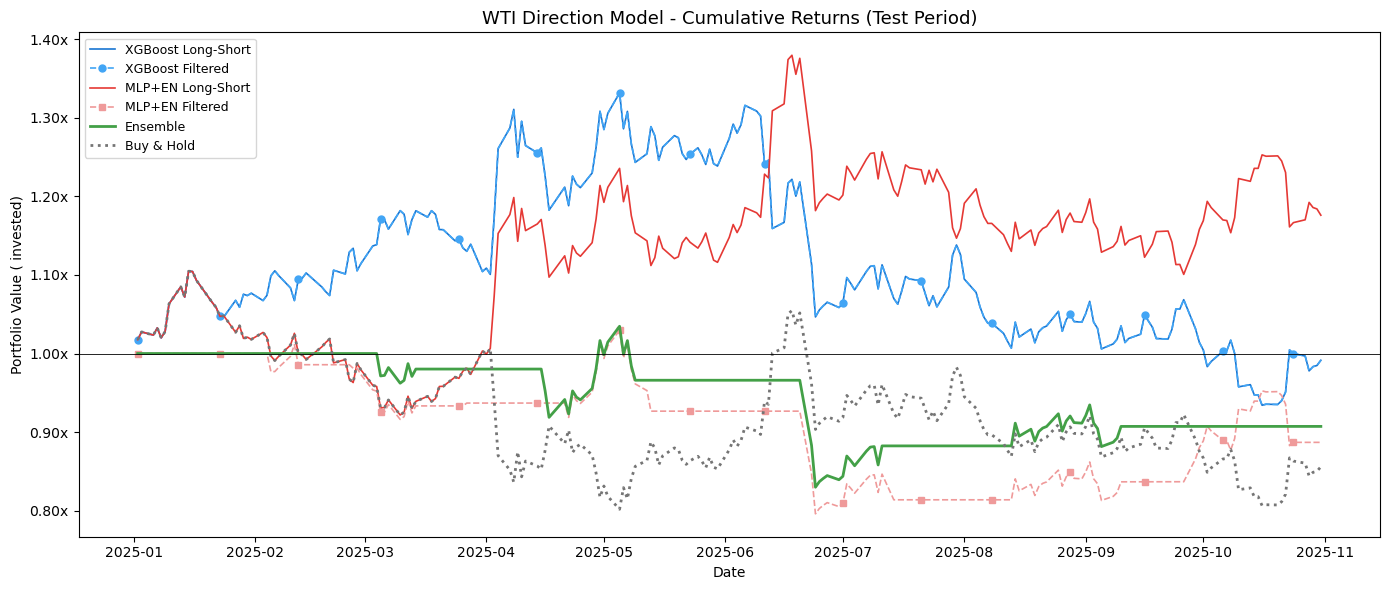

In [50]:
equity_curves = {
    "XGBoost Long-Short" : cumulative_returns(ret_xgb_ls),
    "XGBoost Filtered"   : cumulative_returns(ret_xgb_filt),
    "MLP+EN Long-Short"  : cumulative_returns(ret_mlpen_ls),
    "MLP+EN Filtered"    : cumulative_returns(ret_mlpen_filt),
    "Ensemble"           : cumulative_returns(ret_ensemble),
    "Buy & Hold"         : cumulative_returns(ret_bnh),
}

COLORS = {
    "XGBoost Long-Short" : "#1976D2",
    "XGBoost Filtered"   : "#42A5F5",
    "MLP+EN Long-Short"  : "#E53935",
    "MLP+EN Filtered"    : "#EF9A9A",
    "Ensemble"           : "#43A047",
    "Buy & Hold"         : "#757575",
}
STYLES = {
    "XGBoost Long-Short" : "-",
    "XGBoost Filtered"   : "--",
    "MLP+EN Long-Short"  : "-",
    "MLP+EN Filtered"    : "--",
    "Ensemble"           : "-",
    "Buy & Hold"         : ":",
}
MARKERS = {
    "XGBoost Long-Short" : None,
    "XGBoost Filtered"   : "o",
    "MLP+EN Long-Short"  : None,
    "MLP+EN Filtered"    : "s",
    "Ensemble"           : None,
    "Buy & Hold"         : None,
}

n = len(test_data)
every = max(1, n // 15)  # place ~15 markers along each line

fig, ax = plt.subplots(figsize=(14, 6))
for name, curve in equity_curves.items():
    ax.plot(curve.index, curve.values,
            label=name,
            color=COLORS[name],
            linestyle=STYLES[name],
            linewidth=2 if name in ("Ensemble", "Buy & Hold") else 1.2,
            marker=MARKERS[name],
            markevery=every,
            markersize=5)

ax.axhline(1.0, color="black", linewidth=0.6, linestyle="-")
ax.set_ylabel("Portfolio Value ( invested)")
ax.set_xlabel("Date")
ax.set_title("WTI Direction Model - Cumulative Returns (Test Period)", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}x"))
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("data/fig_investment_strategy.png", dpi=150)
plt.show()


## 8. Drawdown Chart

Maximum drawdown visualises the worst peak-to-trough loss each strategy experienced during the test period.

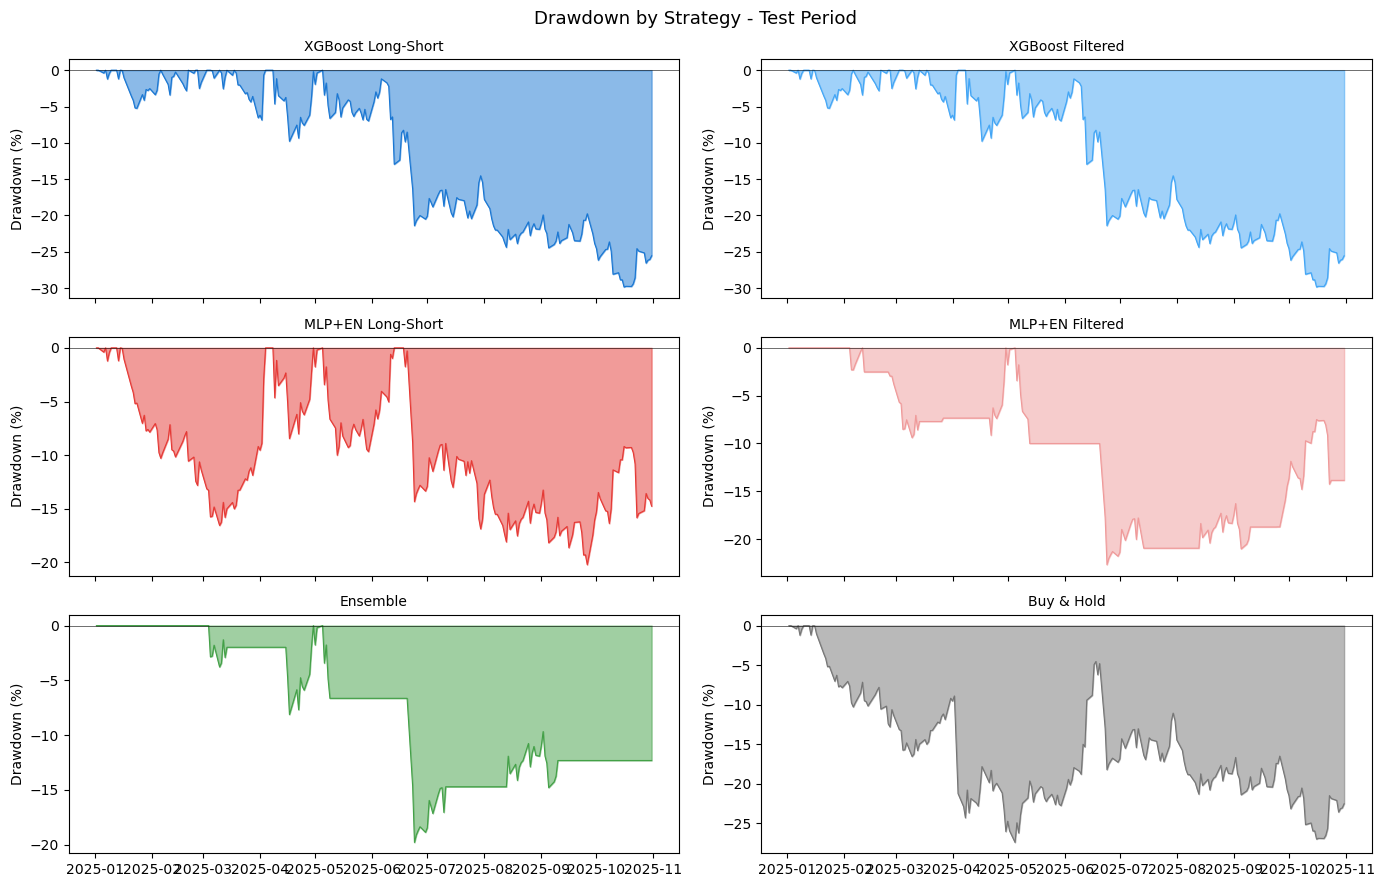

In [51]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, (name, curve) in zip(axes, equity_curves.items()):
    rolling_max = curve.cummax()
    drawdown    = (curve - rolling_max) / rolling_max * 100
    ax.fill_between(drawdown.index, drawdown.values, 0,
                    color=COLORS[name], alpha=0.5)
    ax.plot(drawdown.index, drawdown.values, color=COLORS[name], linewidth=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Drawdown (%)")
    ax.axhline(0, color="black", linewidth=0.4)

fig.suptitle("Drawdown by Strategy - Test Period", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_drawdown.png", dpi=150)
plt.show()

## 9. Rolling Sharpe Ratio

A 60-day rolling Sharpe ratio shows whether the strategy's risk-adjusted edge is stable over time or concentrated in specific sub-periods. Persistent positive values indicate consistent alpha; frequent sign changes suggest the edge is intermittent.
Grey dashed lines mark Sharpe = ±1 as reference thresholds.

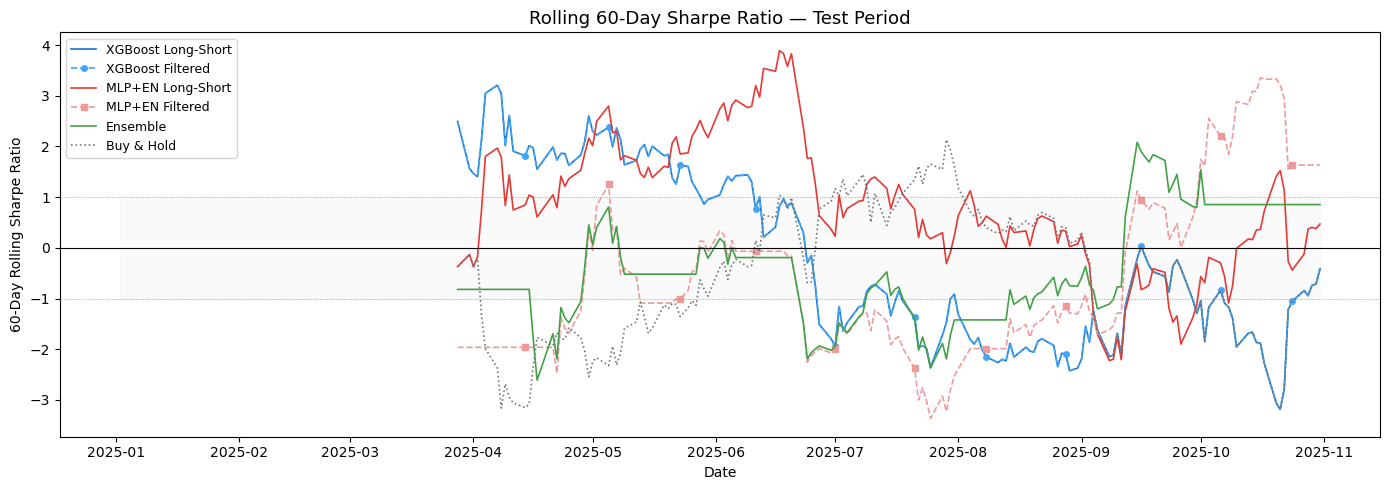

In [52]:
def rolling_sharpe(strat_ret: pd.Series, window: int = 60) -> pd.Series:
    """Compute annualised Sharpe ratio over a rolling window.

    Args:
        strat_ret: Daily strategy return Series.
        window: Rolling window in trading days. Defaults to 60.

    Returns:
        Series of rolling annualised Sharpe ratios.
    """
    roll_mean = strat_ret.rolling(window).mean()
    roll_std  = strat_ret.rolling(window).std()
    return (roll_mean / roll_std * np.sqrt(252)).rename("rolling_sharpe")


WINDOW = 60

roll_series = {
    "XGBoost Long-Short" : rolling_sharpe(ret_xgb_ls,    WINDOW),
    "XGBoost Filtered"   : rolling_sharpe(ret_xgb_filt,  WINDOW),
    "MLP+EN Long-Short"  : rolling_sharpe(ret_mlpen_ls,   WINDOW),
    "MLP+EN Filtered"    : rolling_sharpe(ret_mlpen_filt, WINDOW),
    "Ensemble"           : rolling_sharpe(ret_ensemble,   WINDOW),
    "Buy & Hold"         : rolling_sharpe(ret_bnh,        WINDOW),
}

fig, ax = plt.subplots(figsize=(14, 5))
for name, series in roll_series.items():
    every = max(1, len(series) // 15)
    ax.plot(series.index, series.values,
            label=name, color=COLORS[name],
            linestyle=STYLES[name], linewidth=1.2,
            marker=MARKERS[name], markevery=every, markersize=4)

ax.axhline(0,  color="black", linewidth=0.8)
ax.axhline( 1, color="gray",  linewidth=0.5, linestyle=":")
ax.axhline(-1, color="gray",  linewidth=0.5, linestyle=":")
ax.fill_between(series.index, -1, 1, alpha=0.04, color="gray")
ax.set_ylabel(f"{WINDOW}-Day Rolling Sharpe Ratio")
ax.set_xlabel("Date")
ax.set_title(f"Rolling {WINDOW}-Day Sharpe Ratio — Test Period", fontsize=13)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("data/fig_rolling_sharpe.png", dpi=150)
plt.show()


## 10. Monthly Returns Heatmap

Each cell shows the compounded return for one calendar month. Green = positive, red = negative. This view makes it easy to spot which months drove overall performance and whether strategies move together or diverge.

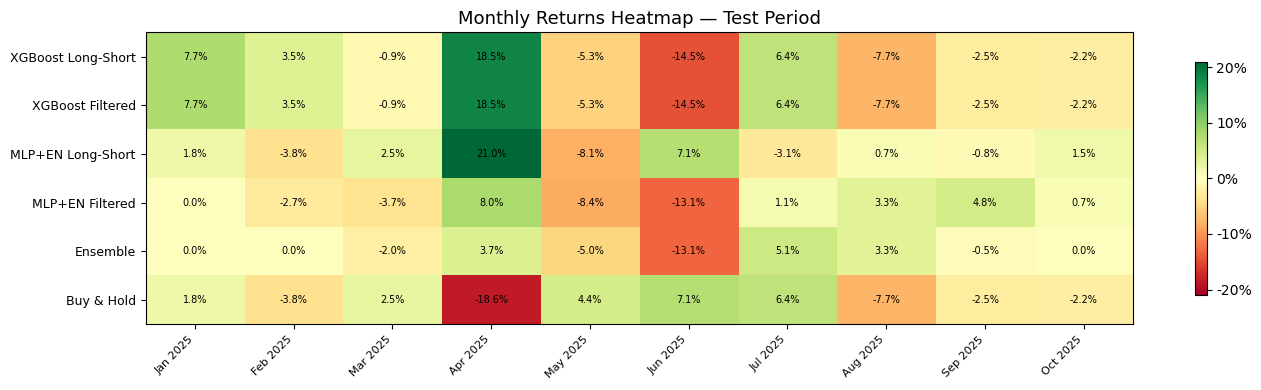

In [53]:
def monthly_returns_table(ret_dict: dict) -> pd.DataFrame:
    """Compute a strategy x month table of compounded monthly returns.

    Args:
        ret_dict: Dict mapping strategy name to daily return Series.

    Returns:
        DataFrame with strategies as rows and month-end dates as columns,
        values representing compounded returns for each month.
    """
    rows = {}
    for name, ret in ret_dict.items():
        rows[name] = ret.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    return pd.DataFrame(rows).T


ret_dict_test = {
    "XGBoost Long-Short" : ret_xgb_ls,
    "XGBoost Filtered"   : ret_xgb_filt,
    "MLP+EN Long-Short"  : ret_mlpen_ls,
    "MLP+EN Filtered"    : ret_mlpen_filt,
    "Ensemble"           : ret_ensemble,
    "Buy & Hold"         : ret_bnh,
}

monthly_tbl = monthly_returns_table(ret_dict_test)
monthly_tbl.columns = [c.strftime("%b %Y") for c in monthly_tbl.columns]

vmax = monthly_tbl.abs().max().max()

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(monthly_tbl.values.astype(float),
               cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(monthly_tbl.columns)))
ax.set_xticklabels(monthly_tbl.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(monthly_tbl.index)))
ax.set_yticklabels(monthly_tbl.index, fontsize=9)

for i in range(len(monthly_tbl.index)):
    for j in range(len(monthly_tbl.columns)):
        val = monthly_tbl.values[i, j]
        ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                fontsize=7, color="black")

plt.colorbar(im, ax=ax,
             format=mticker.FuncFormatter(lambda x, _: f"{x:.0%}"),
             shrink=0.8)
ax.set_title("Monthly Returns Heatmap — Test Period", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_monthly_heatmap.png", dpi=150)
plt.show()


## 12. Validation Period Backtest

For reference, we also show performance on the validation period (2015â€“2024). Note that the validation set was used for hyperparameter and threshold selection, so these results are **in-sample for the strategy** and should not be over-interpreted.

In [54]:
v = val_data.copy()

v_positions = {
    "XGBoost Long-Short" : long_short(v["xgb_pred"]),
    "XGBoost Filtered"   : confidence_filter(v["xgb_pred"],  v["xgb_prob"],  best_thresh_xgb),
    "MLP+EN Long-Short"  : long_short(v["mlpen_pred"]),
    "MLP+EN Filtered"    : confidence_filter(v["mlpen_pred"], v["mlpen_prob"], best_thresh_mlpen),
    "Ensemble"           : ensemble(v["xgb_prob"], v["mlpen_prob"], threshold=best_thresh_ens),
    "Buy & Hold"         : pd.Series(1.0, index=v.index),
}

val_metrics = {
    name: compute_metrics(strategy_returns(pos, v["daily_return"]), pos)
    for name, pos in v_positions.items()
}

val_metrics_df = pd.DataFrame(val_metrics).T
print("=== Validation Period Performance (in-sample for strategy) ===")
val_metrics_df

=== Validation Period Performance (in-sample for strategy) ===


,Total Return,Sharpe Ratio,Max Drawdown,Win Rate,Days Traded
XGBoost Long-Short,-47.5%,0.213,-94.1%,53.3%,2635
XGBoost Filtered,-47.5%,0.213,-94.1%,53.3%,2635
MLP+EN Long-Short,62.7%,0.427,-84.5%,51.5%,2635
MLP+EN Filtered,415.3%,0.695,-35.6%,52.3%,977
Ensemble,235.3%,0.555,-39.2%,52.3%,916
Buy & Hold,33.8%,0.296,-84.8%,52.9%,2635


In [55]:
# Threshold and days-traded breakdown
print(f"Tuned thresholds (selected on this val set):")
print(f"  XGBoost   : {best_thresh_xgb:.2f}")
print(f"  MLP+EN    : {best_thresh_mlpen:.2f}")
print(f"  Ensemble  : {best_thresh_ens:.2f}")
print()
print(f"Total val days: {len(v)}")
print()
print("Days traded per strategy:")
for name, pos in v_positions.items():
    traded = int((pos != 0).sum())
    pct    = traded / len(v) * 100
    print(f"  {name:<25} {traded:>5} / {len(v)}  ({pct:.1f}%)")


Tuned thresholds (selected on this val set):
  XGBoost   : 0.00
  MLP+EN    : 0.05
  Ensemble  : 0.03

Total val days: 2635

Days traded per strategy:
  XGBoost Long-Short         2635 / 2635  (100.0%)
  XGBoost Filtered           2635 / 2635  (100.0%)
  MLP+EN Long-Short          2635 / 2635  (100.0%)
  MLP+EN Filtered             977 / 2635  (37.1%)
  Ensemble                    916 / 2635  (34.8%)
  Buy & Hold                 2635 / 2635  (100.0%)


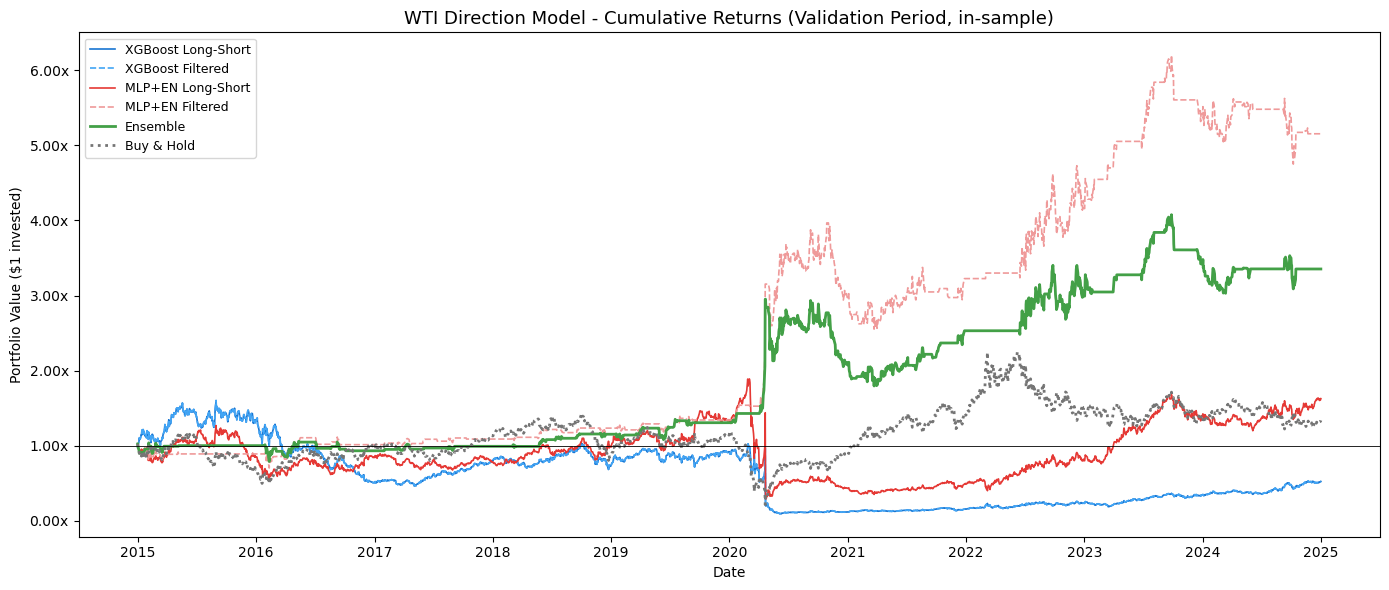

In [56]:
# Cumulative equity curves for the validation period
fig, ax = plt.subplots(figsize=(14, 6))
for name, pos in v_positions.items():
    curve = cumulative_returns(strategy_returns(pos, v["daily_return"]))
    ax.plot(curve.index, curve.values,
            label=name, color=COLORS[name],
            linestyle=STYLES[name],
            linewidth=2 if name in ("Ensemble", "Buy & Hold") else 1.2)

ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_ylabel("Portfolio Value (\$1 invested)")
ax.set_xlabel("Date")
ax.set_title("WTI Direction Model - Cumulative Returns (Validation Period, in-sample)", fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}x"))
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## 13. Transaction Cost Analysis

The strategies above assume frictionless trading. In reality each round-trip trade on WTI futures incurs bid-ask spread, commissions, and slippage — typically **0.05–0.10% per trade**. A cost is deducted on every day the position changes. The existing equity curves are unchanged; this section adds a separate net-of-costs comparison.

In [57]:
def net_strategy_returns(position: pd.Series, daily_return: pd.Series,
                          cost_per_trade: float = 0.0005) -> pd.Series:
    """Compute strategy returns after deducting a per-trade transaction cost.

    A cost is incurred on any day the position changes (including first entry).

    Args:
        position: Series of positions (+1, 0, -1) indexed by date.
        daily_return: Series of underlying asset daily returns indexed by date.
        cost_per_trade: One-way cost as a fraction of notional. Defaults to 0.05%.

    Returns:
        Net daily return Series after transaction costs.
    """
    trades = position.diff().abs()
    trades.iloc[0] = abs(position.iloc[0])   # entry cost on day 1
    return (position * daily_return - trades * cost_per_trade).rename("net_return")


COST = 0.0005   # 0.05% per trade

positions_map = {
    "XGBoost Long-Short" : pos_xgb_ls,
    "XGBoost Filtered"   : pos_xgb_filt,
    "MLP+EN Long-Short"  : pos_mlpen_ls,
    "MLP+EN Filtered"    : pos_mlpen_filt,
    "Ensemble"           : pos_ensemble,
    "Buy & Hold"         : pos_bnh,
}

gross_rets_map = {
    "XGBoost Long-Short" : ret_xgb_ls,
    "XGBoost Filtered"   : ret_xgb_filt,
    "MLP+EN Long-Short"  : ret_mlpen_ls,
    "MLP+EN Filtered"    : ret_mlpen_filt,
    "Ensemble"           : ret_ensemble,
    "Buy & Hold"         : ret_bnh,
}

net_rets = {
    name: net_strategy_returns(pos, d["daily_return"], COST)
    for name, pos in positions_map.items()
}

net_metrics  = {name: compute_metrics(ret, positions_map[name]) for name, ret in net_rets.items()}
net_df  = pd.DataFrame(net_metrics).T

print(f"Transaction cost: {COST:.2%} per trade\n")
compare = pd.concat(
    [metrics_df[["Total Return", "Sharpe Ratio", "Max Drawdown"]].add_suffix(" (Gross)"),
     net_df[["Total Return",     "Sharpe Ratio", "Max Drawdown"]].add_suffix(" (Net)")],
    axis=1
).sort_index(axis=1)
compare


Transaction cost: 0.05% per trade



,Max Drawdown (Gross),Max Drawdown (Net),Sharpe Ratio (Gross),Sharpe Ratio (Net),Total Return (Gross),Total Return (Net)
XGBoost Long-Short,-29.8%,-30.1%,0.131,0.100,-0.9%,-1.7%
XGBoost Filtered,-29.8%,-30.1%,0.131,0.100,-0.9%,-1.7%
MLP+EN Long-Short,-20.2%,-20.5%,0.745,0.726,17.6%,17.0%
MLP+EN Filtered,-22.7%,-22.8%,-0.520,-0.573,-11.3%,-12.2%
Ensemble,-19.8%,-19.9%,-0.490,-0.514,-9.3%,-9.6%
Buy & Hold,-27.4%,-27.4%,-0.397,-0.399,-14.4%,-14.5%


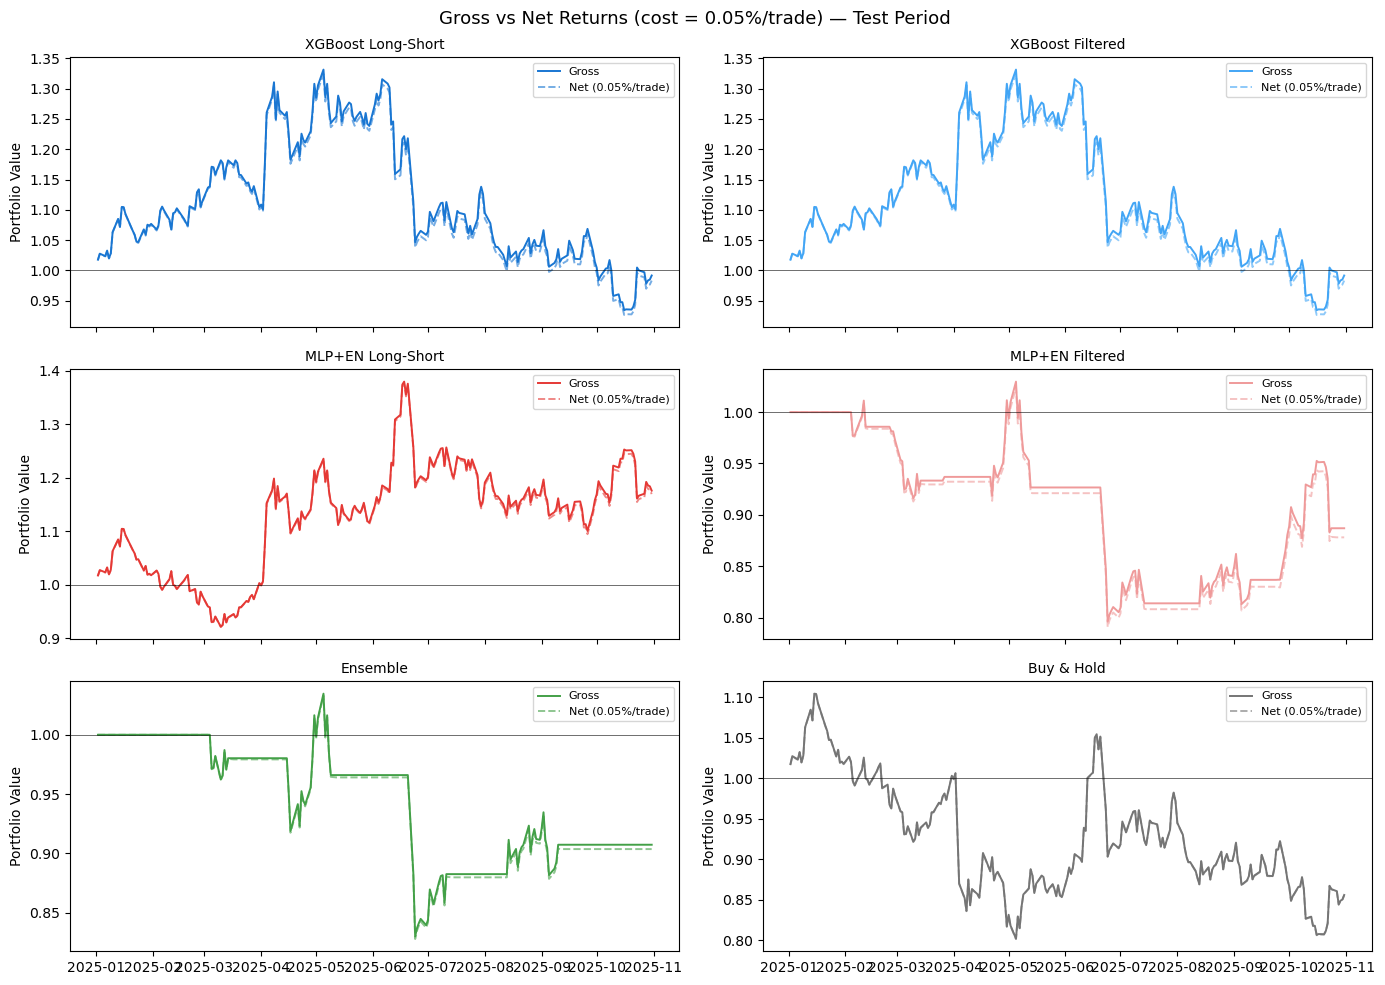

In [58]:
# Gross vs net equity curves per strategy
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for ax, name in zip(axes, positions_map):
    gross_curve = cumulative_returns(gross_rets_map[name])
    net_curve   = cumulative_returns(net_rets[name])
    ax.plot(gross_curve.index, gross_curve.values,
            color=COLORS[name], linewidth=1.4, label="Gross")
    ax.plot(net_curve.index, net_curve.values,
            color=COLORS[name], linewidth=1.4, linestyle="--",
            alpha=0.6, label=f"Net ({COST:.2%}/trade)")
    ax.axhline(1.0, color="black", linewidth=0.4)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Portfolio Value")
    ax.legend(fontsize=8)

fig.suptitle(f"Gross vs Net Returns (cost = {COST:.2%}/trade) — Test Period", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_net_vs_gross.png", dpi=150)
plt.show()


# 14. Summary of the Test Period


In [59]:
print("=== Final Summary: Test Period ===")
print(f"Period: {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Confidence threshold - XGBoost  : {best_thresh_xgb:.2f}")
print(f"Confidence threshold - MLP+EN   : {best_thresh_mlpen:.2f}")
print(f"Confidence threshold - Ensemble : {best_thresh_ens:.2f}")
print()
print(metrics_df.to_string())

=== Final Summary: Test Period ===
Period: 2025-01-02 to 2025-10-31
Confidence threshold - XGBoost  : 0.00
Confidence threshold - MLP+EN   : 0.05
Confidence threshold - Ensemble : 0.03

                   Total Return Sharpe Ratio Max Drawdown Win Rate Days Traded
XGBoost Long-Short        -0.9%        0.131       -29.8%    49.1%         216
XGBoost Filtered          -0.9%        0.131       -29.8%    49.1%         216
MLP+EN Long-Short         17.6%        0.745       -20.2%    52.3%         216
MLP+EN Filtered          -11.3%       -0.520       -22.7%    53.3%          92
Ensemble                  -9.3%       -0.490       -19.8%    57.4%          61
Buy & Hold               -14.4%       -0.397       -27.4%    49.5%         216
